In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

nodes = pd.read_csv("nodes.csv")
edges = pd.read_csv("edges.csv")

In [5]:
G = nx.from_pandas_edgelist(
    edges,
    source="Source",
    target="Target",
    create_using=nx.DiGraph()
)

print("Graph:", G.number_of_nodes(), G.number_of_edges())

Graph: 194377 192184


In [6]:
base_models = [n for n in G.nodes() if G.in_degree(n) == 0]

print("Base models:", len(base_models))

Base models: 30170


In [7]:
descendant_counts = []

for n in base_models:
    descendants = nx.descendants(G, n)
    descendant_counts.append((n, len(descendants)))

In [8]:
top_5 = sorted(descendant_counts, key=lambda x: x[1], reverse=True)[:5]

print("Top 5 base models:")
for model, count in top_5:
    print(model, count)

Top 5 base models:
Qwen/Qwen2.5-7B 7763
Qwen/Qwen3-4B-Instruct-2507 7540
meta-llama/Llama-3.1-8B 6613
Qwen/Qwen2.5-0.5B 4677
mistralai/Mistral-7B-v0.1 4168


In [9]:
top_base_ids = [model for model, _ in top_5]

all_nodes = set()

for model in top_base_ids:
    descendants = nx.descendants(G, model)
    all_nodes.update(descendants)
    all_nodes.add(model)

G_top = G.subgraph(all_nodes).copy()

print("Subgraph:", G_top.number_of_nodes(), G_top.number_of_edges())

Subgraph: 30762 32937


In [10]:
color_list = ["red", "blue", "green", "orange", "purple"]
colors_map = {}

for i, base in enumerate(top_base_ids):
    lineage = nx.descendants(G, base)
    lineage.add(base)
    
    for node in lineage:
        colors_map[node] = color_list[i]

In [11]:
node_sizes = []
node_colors = []

for n in G_top.nodes():
    if n in top_base_ids:
        node_sizes.append(400)   # base models big
    else:
        node_sizes.append(30)    # others small
    
    node_colors.append(colors_map.get(n, "gray"))

In [12]:
# reduce to most important nodes
degree_dict = dict(G_top.degree())

top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:1000]

G_plot = G_top.subgraph(top_nodes).copy()

print("Plot graph:", G_plot.number_of_nodes(), G_plot.number_of_edges())

Plot graph: 1000 2077


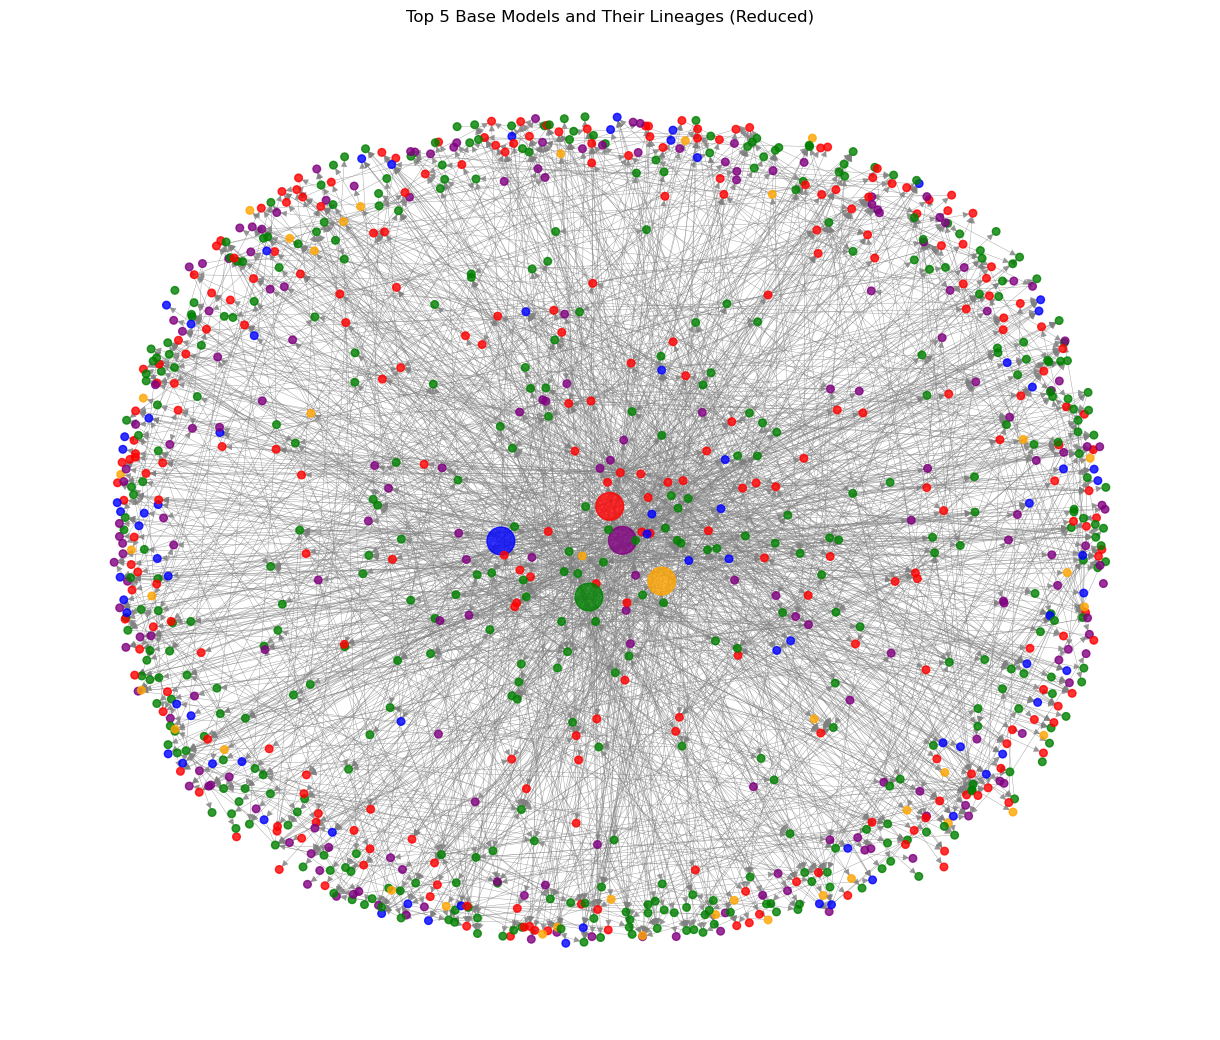

In [13]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G_plot, seed=42, k=0.5)

node_sizes_plot = [
    400 if n in top_base_ids else 30
    for n in G_plot.nodes()
]

node_colors_plot = [
    colors_map.get(n, "gray")
    for n in G_plot.nodes()
]

nx.draw(
    G_plot,
    pos,
    node_size=node_sizes_plot,
    node_color=node_colors_plot,
    edge_color="gray",
    width=0.3,
    alpha=0.8,
    with_labels=False
)

plt.title("Top 5 Base Models and Their Lineages (Reduced)")
plt.show()

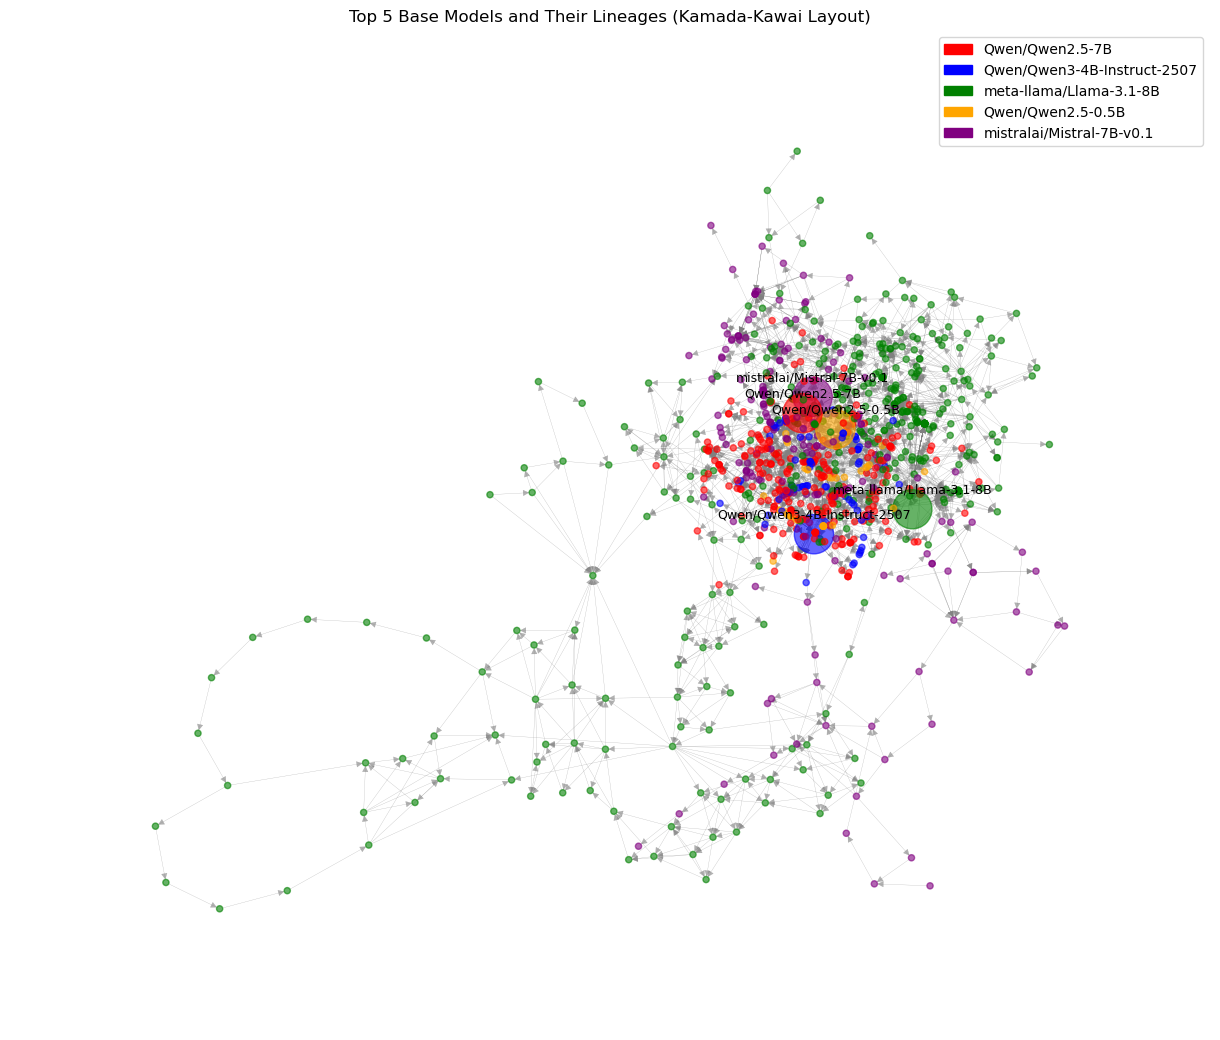

In [ ]:
plt.figure(figsize=(12, 10))

pos = nx.kamada_kawai_layout(G_plot)

node_sizes_plot = [
    800 if n in top_base_ids else 20
    for n in G_plot.nodes()
]

node_colors_plot = [
    colors_map.get(n, "gray")
    for n in G_plot.nodes()
]

nx.draw(
    G_plot,
    pos,
    node_size=node_sizes_plot,
    node_color=node_colors_plot,
    edge_color="gray",
    width=0.2,
    alpha=0.6,
    with_labels=False
)

# label only base models
labels = {n: str(n) for n in top_base_ids}
pos_labels = {
    n: (x, y + 0.03)  # shift labels upward
    for n, (x, y) in pos.items()
    if n in top_base_ids
}

nx.draw_networkx_labels(
    G_plot,
    pos_labels,
    labels={n: str(n) for n in top_base_ids},
    font_size=9,
    font_weight='demi'
)

# legend
import matplotlib.patches as mpatches
legend_elements = [
    mpatches.Patch(color=colors_map[base], label=str(base))
    for base in top_base_ids
]
plt.legend(handles=legend_elements, loc='upper right')

plt.title("Top 5 Base Models and Their Lineages (Kamada-Kawai Layout)")
plt.margins(0.1)
plt.show()

Graph: 194377 192184
Base models: 30170

Top base models:
Qwen/Qwen2.5-7B 7763
Qwen/Qwen3-4B-Instruct-2507 7540
meta-llama/Llama-3.1-8B 6613
Qwen/Qwen2.5-0.5B 4677
mistralai/Mistral-7B-v0.1 4168

Lineage size: 7764
Tree size: 129


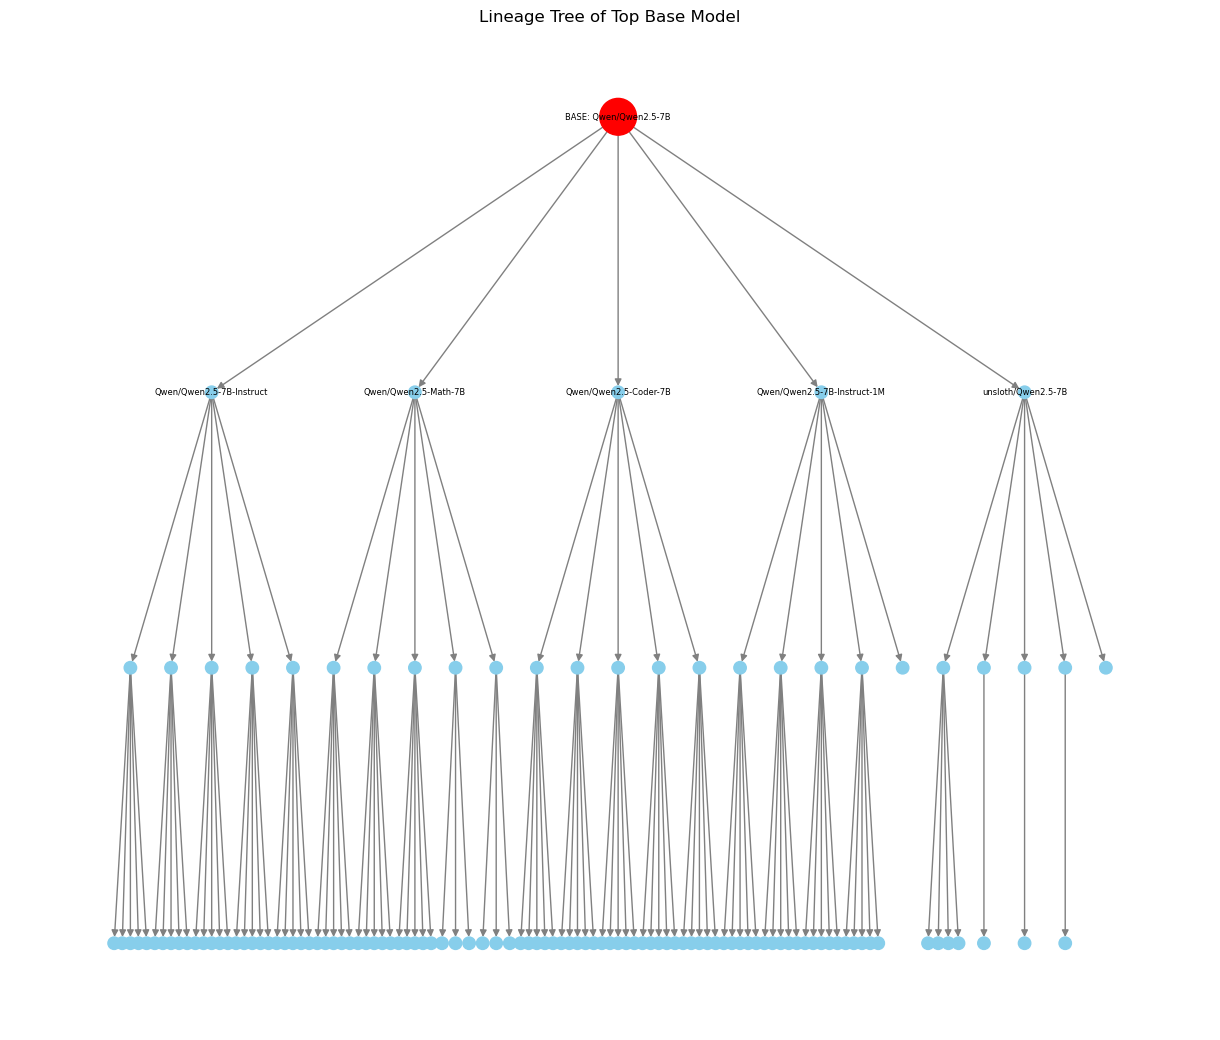

In [15]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
nodes = pd.read_csv("nodes.csv")
edges = pd.read_csv("edges.csv")

# optional: map IDs to names (adjust column name if needed)
if "Name" in nodes.columns:
    id_to_name = dict(zip(nodes["Id"], nodes["Name"]))
else:
    id_to_name = {i: str(i) for i in nodes["Id"]}

# -----------------------------
# 2. BUILD GRAPH
# -----------------------------
G = nx.from_pandas_edgelist(
    edges,
    source="Source",
    target="Target",
    create_using=nx.DiGraph()
)

print("Graph:", G.number_of_nodes(), G.number_of_edges())

# -----------------------------
# 3. FIND BASE MODELS
# -----------------------------
base_models = [n for n in G.nodes() if G.in_degree(n) == 0]
print("Base models:", len(base_models))

# -----------------------------
# 4. COUNT DESCENDANTS
# -----------------------------
descendant_counts = []

for n in base_models:
    descendants = nx.descendants(G, n)
    descendant_counts.append((n, len(descendants)))

# -----------------------------
# 5. TOP BASE MODEL
# -----------------------------
top_5 = sorted(descendant_counts, key=lambda x: x[1], reverse=True)[:5]

print("\nTop base models:")
for model, count in top_5:
    print(model, count)

top_base = top_5[0][0]

# -----------------------------
# 6. BUILD LINEAGE SUBGRAPH
# -----------------------------
descendants = nx.descendants(G, top_base)
sub_nodes = descendants.union({top_base})
G_sub = G.subgraph(sub_nodes).copy()

print("\nLineage size:", G_sub.number_of_nodes())

# -----------------------------
# 7. PRUNED TREE (KEY FIX)
# -----------------------------
def limited_bfs_tree(G, root, max_children=5, depth_limit=3):
    tree = nx.DiGraph()
    tree.add_node(root)
    
    visited = set([root])
    current_level = [root]
    
    for _ in range(depth_limit):
        next_level = []
        
        for node in current_level:
            children = sorted(
                G.successors(node),
                key=lambda x: G.out_degree(x),
                reverse=True
            )
            
            count = 0
            for child in children:
                if child not in visited:
                    tree.add_edge(node, child)
                    next_level.append(child)
                    visited.add(child)
                    count += 1
                
                if count >= max_children:
                    break
        
        current_level = next_level
    
    return tree

tree = limited_bfs_tree(G_sub, top_base, max_children=5, depth_limit=3)

print("Tree size:", tree.number_of_nodes())

# -----------------------------
# 8. HIERARCHICAL LAYOUT
# -----------------------------
def hierarchy_pos(G, root, width=1., vert_gap=0.5, vert_loc=0, xcenter=0.5):
    pos = {root: (xcenter, vert_loc)}

    def _hierarchy_pos(G, root, left, right, vert_loc, pos):
        children = list(G.successors(root))
        if len(children) != 0:
            dx = (right - left) / len(children)
            nextx = left + dx / 2
            for child in children:
                pos[child] = (nextx, vert_loc - vert_gap)
                pos = _hierarchy_pos(G, child, nextx - dx/2, nextx + dx/2, vert_loc - vert_gap, pos)
                nextx += dx
        return pos

    return _hierarchy_pos(G, root, 0, width, vert_loc, pos)

pos = hierarchy_pos(tree, top_base, vert_gap=0.7)

# -----------------------------
# 9. NODE STYLING
# -----------------------------
node_sizes = [
    700 if n == top_base else 80
    for n in tree.nodes()
]

node_colors = [
    "red" if n == top_base else "skyblue"
    for n in tree.nodes()
]

# -----------------------------
# 10. LABELING (SMART)
# -----------------------------
degree_dict = dict(tree.degree())

# top important nodes
top_labels = sorted(degree_dict, key=degree_dict.get, reverse=True)[:8]

labels = {}

for n in tree.nodes():
    # always label base
    if n == top_base:
        labels[n] = "BASE: " + id_to_name.get(n, str(n))
    
    # label only first layer (children of base)
    elif n in list(tree.successors(top_base)):
        labels[n] = id_to_name.get(n, str(n))

# -----------------------------
# 11. PLOT
# -----------------------------
plt.figure(figsize=(12, 10))

nx.draw(
    tree,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edge_color="gray",
    width=1.0,
    with_labels=False
)

nx.draw_networkx_labels(
    tree,
    pos,
    labels=labels,
    font_size=6
)

plt.title("Lineage Tree of Top Base Model")
plt.show()